## Binary Digit Recognition
- Using only two set of image data type to recognize 1 and 0
- Activation Function for Hidden layer & Output layer: Sigmoid
- Loss Function: Binary Crossentropy
- Used Kaggle Kernel for execution
- Used Tensorflow for model creation
- Dataset: MNIST (filtered for 1 and 0 only)

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## Data Exploration
- Load the data
- Filter the data to only include images of 1 and 0
- Prepare the data for displaying images (reshape)
- Display the first 10 images with their labels

In [2]:
input_data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv') # if not using kaggle use "/data/digit-recognizer-data/train.csv"
input_data.head()

data = input_data.to_numpy()
filtered_data = data[(data[:, 0] == 1) | (data[:, 0] == 0)]

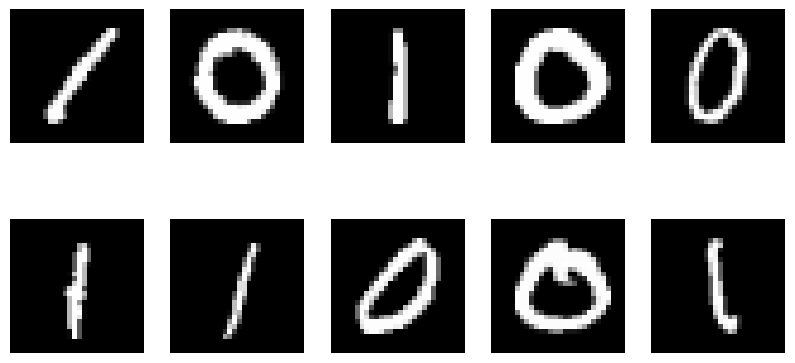

In [3]:
# get x by ignoring the first column which contains the labels
x = filtered_data[:, 1:]
# get y by selecting the first column which contains the labels
y = filtered_data[:, 0]

# Reshape each row to a 28x28 image
x_images = x.reshape(-1, 28, 28)

# Set up a grid for displaying the first 10 images (e.g., 2 rows and 5 columns)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))

# Plot the first 10 images
for i, ax in enumerate(axes.flat):
    ax.imshow(x_images[i], cmap='gray')  # Show image in grayscale
    ax.axis('off')  # Hide axis for a cleaner look

plt.show()

## Model Creation
- Create a Sequential model with 3 layers
- First layer: 25 units, Sigmoid activation function
- Second layer: 15 units, Sigmoid activation function
- Third layer: 1 unit, Sigmoid activation function
- Optimizer: Adam with learning rate 0.001
- Loss Function: Binary Crossentropy
- Train the model for 9 epochs

In [4]:
model = Sequential([
    Dense(units=25, activation='sigmoid'),
    Dense(units=15, activation='sigmoid'),
    Dense(units=1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,loss = BinaryCrossentropy())
model.fit(x, y, epochs=9)
model.summary()

Epoch 1/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2794
Epoch 2/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0350
Epoch 3/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150
Epoch 4/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0096
Epoch 5/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0073
Epoch 6/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0070
Epoch 7/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050
Epoch 8/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038
Epoch 9/9
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,095 (234.75 KB)

 Trainable params: 20,031 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,064 (156.50 KB)

## Model Evaluation
- Get the output of the model for the test data
- Display the first 100 images with the predicted labels and target labels
- The title of each image should show the target and predicted labels

In [5]:
print(x[:0].shape)

def GetOutput(input):
    predictions = model.predict(input)
    yhat = np.zeros_like(predictions)
    for i in range(len(predictions)):
        if predictions[i] >= 0.5:
            yhat[i] = 1
        else:
            yhat[i] = 0
    return yhat


(0, 784)


276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


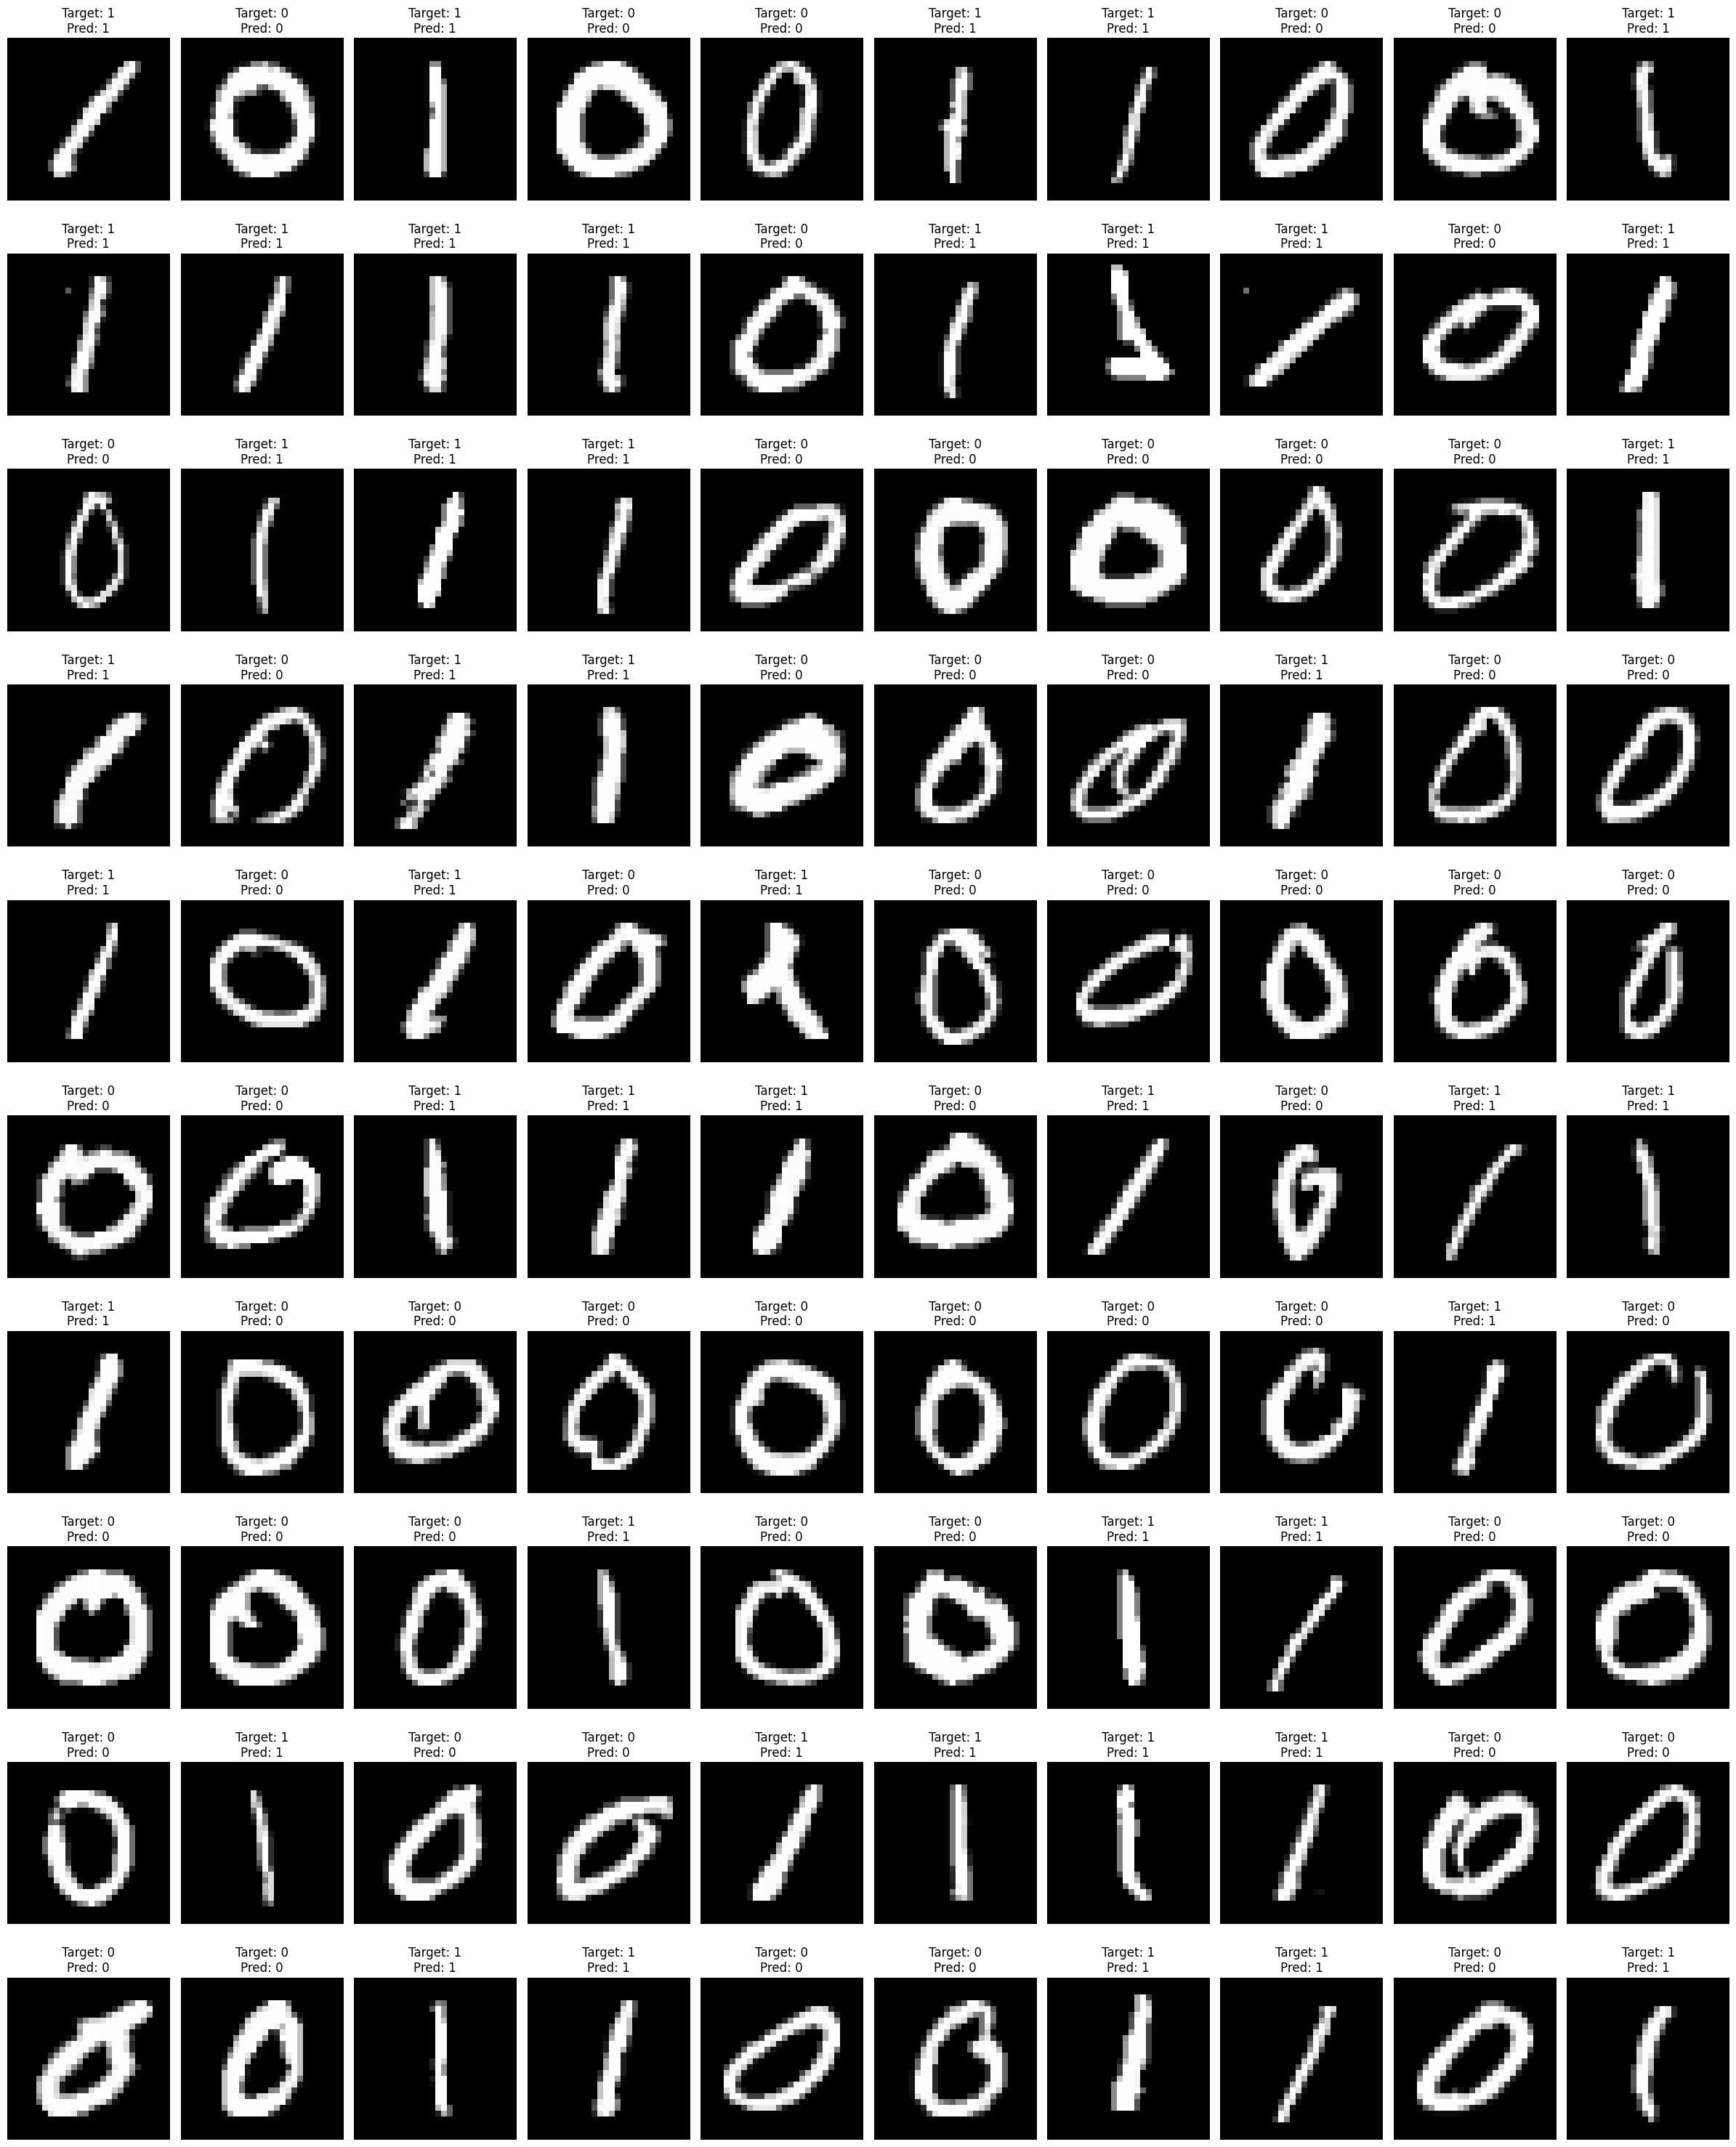

In [6]:
testData = pd.read_csv('/kaggle/input/digit-recognizer/test.csv') # if not using kaggle use "/data/digit-recognizer-data/test.csv"
filtered_test_data = data[(data[:, 0] == 1) | (data[:, 0] == 0)]
# get x by ignoring the first column which contains the labels  
x_test = filtered_test_data[:, 1:]
# get y by selecting the first column which contains the labels
y_target = filtered_test_data[:, 0]

yhat = GetOutput(x_test)

# Reshape x_test images to 28x28 for visualization
x_images = x_test.reshape(-1, 28, 28)

# Set up the plot grid (e.g., 10 rows and 10 columns)
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(24, 30))

# Plot the first 100 images with target vs prediction in titles
for i, ax in enumerate(axes.flat):
    ax.imshow(x_images[i], cmap='gray')  # Show the image in grayscale
    ax.axis('off')  # Hide axes
    # Set title to show target vs prediction
    ax.set_title(f"Target: {int(y_target[i])}\nPred: {int(yhat[i][0])}")  # Extract first element for prediction

plt.tight_layout()
plt.show()